# Week3 - Homework Rupesh_koram_HW-3

Write a rule based predictor for the dataset below.

Choose one of the following datasets and do your EDA.
Test your assumptions.

Finally write your code in `predict_one` function.

Do __NOT__ change the function signature! This function should only take name and return `F` or `M`

In [85]:
import pandas as pd
import numpy as np
from matplotlib import pyplot as plt

us_names = 'https://raw.githubusercontent.com/msaricaumbc/DS_data/master/ds602/names/us_names.csv'
# in_names = 'https://raw.githubusercontent.com/msaricaumbc/DS_data/master/ds602/names/in_names.csv'

df = pd.read_csv(us_names)
df.dropna(inplace=True)
df.info()

<class 'pandas.core.frame.DataFrame'>
Int64Index: 27999 entries, 0 to 27999
Data columns (total 2 columns):
 #   Column  Non-Null Count  Dtype 
---  ------  --------------  ----- 
 0   name    27999 non-null  object
 1   gender  27999 non-null  object
dtypes: object(2)
memory usage: 656.2+ KB


In [86]:
df

,name,gender
0,jerilynn,F
1,percy,M
2,landry,M
3,reynalda,F
4,girl,F
...,...,...
27995,emelio,M
27996,holt,M
27997,silvestre,M
27998,annastacia,F


In [87]:
df.nunique()

name      25948
gender        2
dtype: int64

In [88]:
df.gender.value_counts()

M    14000
F    13999
Name: gender, dtype: int64

### Two examples:

In [89]:
df['is_last_letter_vowel'] = [ 'aeiou'.find(name[-1])>0 for name in df.name]

<AxesSubplot:xlabel='is_last_letter_vowel', ylabel='count'>

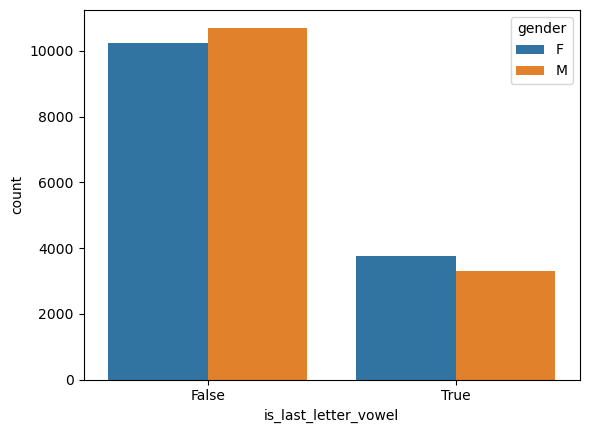

In [90]:
import seaborn as sns

sns.countplot(data = df, x = 'is_last_letter_vowel', hue = 'gender')

It looks like last letter is being a vowel is not a good indicator for this dataset!

<AxesSubplot:xlabel='len', ylabel='count'>

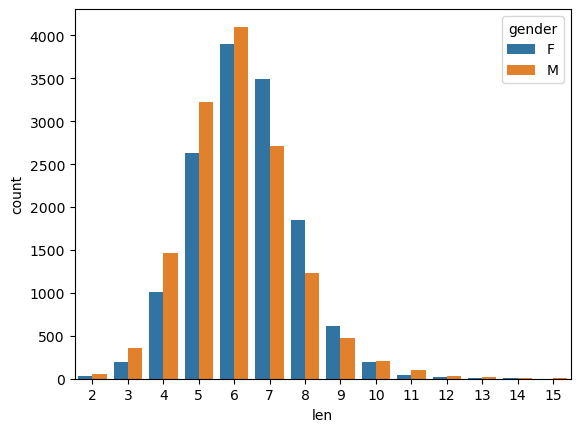

In [91]:
df['len'] = [ len(name) for name in df.name]
sns.countplot(data = df, x = 'len', hue = 'gender')

Seems like length doesn't also seem like a good separator

- having length 4 & 10

In [92]:
def predict_one(name):
    name = name.lower()
    last_letter = name[-1]
    name_length = len(name)
    if last_letter in ['a', 'e','y']:
        return 'F'  #  mostly female with that last letter
    elif last_letter in ['n', 'r','o']:
        return 'M'  #  mostly female with that last letter
    elif name_length <= 4:
        return 'M'  # male
    elif name_length >= 6:
        return 'F'  # female
    else:
        return 'F' 

In [93]:
name_to_predict = 'reynalda' 
predicted_gender = predict_one(name_to_predict)
print(f"Predicted gender for {name_to_predict}: {predicted_gender}")

Predicted gender for reynalda: F


In [94]:
predictions = [ predict_one(name) for name in df.name]
accuracy = sum(df.gender == predictions) / len(df)
print(f"Accuracy: {accuracy}")

Accuracy: 0.6479159969998929


* changing the length 




In [95]:
def predict_one(name):
    name = name.lower()
    last_letter = name[-1]
    name_length = len(name)
    if last_letter in ['a', 'e','y']:
        return 'F'  
    elif last_letter in ['n', 'r','o']:
        return 'M'  
    elif name_length <= 10:
        return 'M' 
    elif name_length >=6 :
        return 'F'
    else:
        return 'F'  

In [96]:
name_to_predict = 'reynalda' 
predicted_gender = predict_one(name_to_predict)
print(f"Predicted gender for {name_to_predict}: {predicted_gender}")

Predicted gender for reynalda: F


In [97]:
predictions = [ predict_one(name) for name in df.name]
accuracy = sum(df.gender == predictions) / len(df)
print(f"Accuracy: {accuracy}")

Accuracy: 0.7128826029501054


* Through a rule-based approach, I have  observed that many female names tend to end with 'a' and are longer in length than male names and with my Assumptions I got 71 % Accuracy. While changing the length we can observe significan change in accuracy.